# Chest X-Ray Pneumonia Detection

Binary classification of chest X-ray images (Normal vs Pneumonia) using a custom CNN trained with data augmentation.

**Dataset:** [Labeled Chest X-Ray Images](https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images)

In [ ]:
import os
import shutil
import zipfile
import random
import pathlib
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Model building
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Image processing
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import skimage
from skimage import io
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

print("TensorFlow version:", tf.__version__)

2.21.0


In [ ]:
# -- Augmentation Functions --------------------------------------------------

def anticlockwise_rotation(image):
    angle = np.random.randint(1, 30)
    return rotate(image, angle)

def clockwise_rotation(image):
    angle = np.random.randint(1, 30)
    return rotate(image, -angle)

def warp_shift(image):
    transform = AffineTransform(translation=(np.random.randint(-50, 50),
                                              np.random.randint(-50, 50)))
    return warp(image, transform, mode="wrap")

def blur_image(image):
    return cv2.GaussianBlur(image, (9, 9), 0)

def add_brightness(image):
    return adjust_gamma(image, gamma=np.random.uniform(0.5, 1.5))

def flip_up_down(image):
    return np.flipud(image)

def sheared(image):
    transform = AffineTransform(shear=np.random.uniform(-0.3, 0.3))
    return warp(image, transform, mode="wrap")

## 1. Setup & Data Download

In [ ]:
import os
import shutil

# Place your kaggle.json in the same folder as this script,
# then run this cell once

kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

shutil.copy("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)

print("kaggle.json successfully copied to ~/.kaggle/")

In [ ]:
# Uncomment below to upload kaggle.json via Google Colab

# from google.colab import files
# files.upload()

In [4]:
# Download kaggle dataset and unzip the file
# !cp kaggle.json ~/.kaggle/

# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images
!unzip labeled-chest-xray-images.zip

Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other




  0%|          | 0.00/1.17G [00:00<?, ?B/s]
  0%|          | 1.00M/1.17G [00:00<07:47, 2.69MB/s]
  0%|          | 3.00M/1.17G [00:00<02:57, 7.06MB/s]
  0%|          | 5.00M/1.17G [00:00<02:14, 9.28MB/s]
  1%|          | 7.00M/1.17G [00:00<01:55, 10.8MB/s]
  1%|          | 9.00M/1.17G [00:00<01:50, 11.3MB/s]
  1%|          | 11.0M/1.17G [00:01<01:47, 11.6MB/s]
  1%|          | 13.0M/1.17G [00:01<01:45, 11.8MB/s]
  1%|▏         | 15.0M/1.17G [00:01<01:43, 12.0MB/s]
  1%|▏         | 17.0M/1.17G [00:01<01:42, 12.1MB/s]
  2%|▏         | 19.0M/1.17G [00:01<01:42, 12.1MB/s]
  2%|▏         | 21.0M/1.17G [00:02<01:41, 12.2MB/s]
  2%|▏         | 23.0M/1.17G [00:02<01:41, 12.2MB/s]
  2%|▏         | 25.0M/1.17G [00:02<01:41, 12.2MB/s]
  2%|▏         | 27.0M/1.17G [00:02<01:40, 12.2MB/s]
  2%|▏         | 29.0M/1.17G [00:02<01:40, 12.2MB/s]
  3%|▎         | 31.0M/1.17G [00:02<01:40, 12.2MB/s]
  3%|▎         | 33.0M/1.17G [00:03<01:40, 12.2MB/s]
  3%|▎         | 35.0M/1.17G [00:03<01:39, 12.2MB/s]
 

## 2. Data Preparation

In [5]:
import os
import shutil

In [ ]:
# Original train and test directories
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"

# New combined dataset directory
combined_dir = "chest_xray/dataset"

In [ ]:
# Create combined dataset directory
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Copy files from train directory
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Copy files from test directory
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

## 3. Dataset Exploration

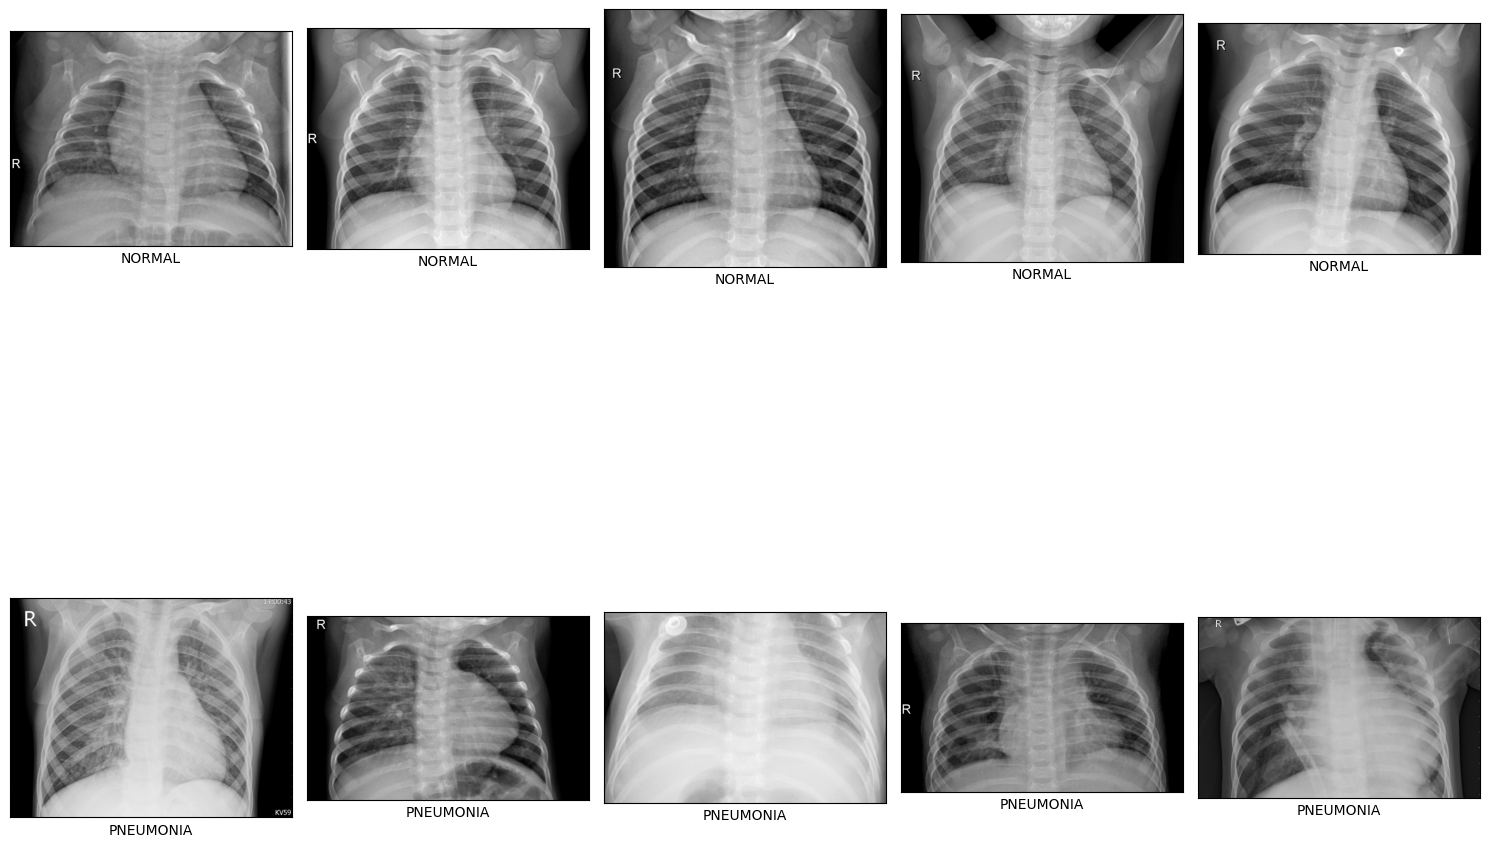

In [12]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_image = {}

# Tentukan path sumber train
path = "chest_xray/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "chest_xray/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

In [ ]:
# Build dict storing image filenames per class
lung_image = {}

# Set source path
path = "chest_xray/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Display 5 random images per class
# Different images shown on each run
path_sub = "chest_xray/dataset/"

# Display 5 random images per class from training data
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Convert to grayscale
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

## 4. Preprocessing

# Define source path
lung_path = "chest_xray/dataset/"

# Build lists for file names, paths, and labels
file_name = []
labels = []
full_path = []

# Walk directory to collect file info, save as DataFrame
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot class distribution
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

images_path = "chest_xray/dataset/NORMAL"              # Path to original images
augmented_path = "chest_xray/dataset/NORMAL_augmented" # Path for augmented images
images = []   # Storage for image paths

os.makedirs(augmented_path, exist_ok=True)

# Read image names from folder and append paths to the images list
for im in os.listdir(images_path):
    images.append(os.path.join(images_path, im))

# Number of augmented images to generate
images_to_generate = 2000
i = 1

In [ ]:
while i <= images_to_generate:
    image = random.choice(images)
    try:
        original_image = io.imread(image)

        # Fix dimensi
        if original_image.ndim == 2:
            original_image = np.stack([original_image] * 3, axis=-1)
        elif original_image.ndim == 3 and original_image.shape[2] == 4:
            original_image = original_image[:, :, :3]

        # Fix dtype → pastikan uint8 sebelum transformasi
        if original_image.dtype != np.uint8:
            original_image = (original_image * 255).clip(0, 255).astype(np.uint8)

        transformed_image = original_image.copy()
        n = 0
        transformation_count = random.randint(1, len(transformations))

        while n <= transformation_count:
            key = random.choice(list(transformations))
            transformed_image = transformations[key](transformed_image)

            # Fix float setelah transformasi
            if transformed_image.dtype != np.uint8:
                transformed_image = (transformed_image * 255).clip(0, 255).astype(np.uint8)

            n += 1

        new_image_path = "%s/augmented_image_%s.jpg" % (augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)
        cv2.imwrite(new_image_path, transformed_image)
        i += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{images_to_generate}")

    except Exception as e:
        print(f'Skipping {image}: {e}')

Skipping chest_xray/dataset/NORMAL\NORMAL-7140141-0002.jpeg: EagerTensor object has no attribute 'clip'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      
Skipping chest_xray/dataset/NORMAL\NORMAL-9194822-0001.jpeg: EagerTensor object has no attribute 'clip'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      
Skipping chest_xray/dataset/NORMAL\NORMAL-8471954-0002.jpeg: EagerTensor object has no attribute 'clip'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.experimental_enable_numpy_behavior()
      
Skipping chest_xray/dataset/NORMAL\NORMAL-6671728-0001.jpeg: EagerTensor object has no attribute 'clip'. 
        If you are looking for numpy-related methods, please run the following:
        tf.experimental.numpy.expe

KeyboardInterrupt: 

### 4.2 Data Splitting

In [ ]:
# Definisikan path sumber
lung_path = "chest_xray/dataset/"
 
# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []
 
# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)
 
distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})
 
# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
# Variables: X = image paths, y = labels
X = distribution_train['path']
y = distribution_train['labels']

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [ ]:
# Define source path
lung_path = "chest_xray/dataset/"
 
# Build lists for file names, paths, and labels
file_name = []
labels = []
full_path = []
 
# Walk directory to collect file info, save as DataFrame
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)
 
distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})
 
# Plot class distribution
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)
 
print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')
 
# Cek sampel data
print(df_all.sample(5))
 
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "chest_xray/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"

In [ ]:
# Combine into DataFrames
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

# Merge train and test DataFrames
df_all = pd.concat([df_tr, df_te], ignore_index=True)
 
print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')
 
# Inspect sample rows
print(df_all.sample(5))
 
# Source dataset path
datasource_path = "chest_xray/dataset/"
# Output path for split dataset
dataset_path = "Dataset-Final/"

In [ ]:
for index, row in tq(df_all.iterrows()):
    # Resolve file path
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path, row['labels'], row['file_name'].split('.')[0])
 
    # Create destination directory
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))
 
    # Determine destination filename
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)
 
    # Copy file to destination
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

In [ ]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)
 
train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)
 
validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)
 
test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

In [ ]:
# Define train and test directories
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"
 
train_normal = os.path.join(TRAIN_DIR + '/NORMAL')
train_pneumonia = os.path.join(TRAIN_DIR + '/PNEUMONIA')
test_normal = os.path.join(TEST_DIR + '/NORMAL')
test_pneumonia = os.path.join(TEST_DIR + '/PNEUMONIA')
 
print("Total number of normal images in training set: ",len(os.listdir(train_normal)))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_pneumonia)))
print("Total number of normal images in test set: ",len(os.listdir(test_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_pneumonia)))

In [ ]:
# Create ImageDataGenerators with normalization
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)
 
train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)
 
validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)
 
test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

In [ ]:
# tf.keras.backend.clear_session()
 
####################### Init sequential model ##################################
model_1 = Sequential()
 
# Convolutional blocks
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))
 
# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))
 
# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))
 
# Flatten layer
model_1.add(Flatten())
# 1nd Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(Dropout(0.5))
# 2nd Dense Layer
model_1.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(Dropout(0.3))
 
# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(Dense(1, activation='sigmoid'))
# Fully connected layers
 
# Compile model
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='binary_crossentropy',
                metrics=['accuracy'])
 
# Summary of the Model Architecture
print(model_1.summary())

In [ ]:
test_generator.reset()
 
preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1
 
# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1]),index=["Actual Normal", "Actual Pneumonia"],
columns=["Predicted Normal", "Predicted Pneumonia"])
sns.heatmap(cm,annot=True,fmt="d")
 
# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['Normal','Pneumonia'], digits=4))

In [ ]:
model_1.save("outputs/models/chest_xray_cnn.keras")
print("Model saved to outputs/models/chest_xray_cnn.keras")

## 6. Results Summary

| Metric | Value |
|--------|-------|
| Test Accuracy | *(fill after training)* |
| Precision (Pneumonia) | *(fill after training)* |
| Recall (Pneumonia) | *(fill after training)* |
| F1-Score (Pneumonia) | *(fill after training)* |